# member 01

In [1]:
import numpy as np
import pandas as pd


In [2]:
from google.colab import files


uploaded = files.upload()

data = pd.read_csv("laptop_price.csv", encoding='ISO-8859-1')


data.head()

Saving laptop_price.csv to laptop_price.csv


,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60


In [3]:
print(data.isnull().sum())


laptop_ID           0
Company             0
Product             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price_euros         0
dtype: int64


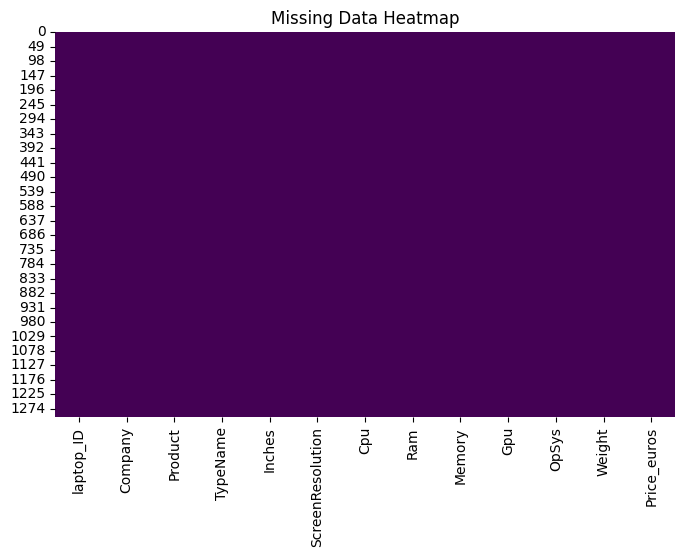

In [4]:
# Visualization
import matplotlib.pyplot as plt # Import matplotlib.pyplot as plt
import seaborn as sns # Import seaborn as sns

plt.figure(figsize=(8,5))
sns.heatmap(data.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Data Heatmap")
plt.show()

# member 02

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   laptop_ID         1303 non-null   int64  
 1   Company           1303 non-null   object 
 2   Product           1303 non-null   object 
 3   TypeName          1303 non-null   object 
 4   Inches            1303 non-null   float64
 5   ScreenResolution  1303 non-null   object 
 6   Cpu               1303 non-null   object 
 7   Ram               1303 non-null   object 
 8   Memory            1303 non-null   object 
 9   Gpu               1303 non-null   object 
 10  OpSys             1303 non-null   object 
 11  Weight            1303 non-null   object 
 12  Price_euros       1303 non-null   float64
dtypes: float64(2), int64(1), object(10)
memory usage: 132.5+ KB


In [6]:
data.head(2)

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94


In [7]:
# Convert RAM and Weight into numeric
data['Ram'] = data['Ram'].str.replace('GB','').astype('int32')
data['Weight'] = data['Weight'].str.replace('kg','').astype('float32')

In [8]:
data.head(2)

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,1339.69
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,898.94


In [9]:
data['Company'].value_counts()

,count
Company,
Dell,297
Lenovo,297
HP,274
Asus,158
Acer,103
MSI,54
Toshiba,48
Apple,21
Samsung,9


In [10]:
# Combine rare companies into "Other"
def add_company(inpt):
    if inpt in ['Samsung','Razer','Mediacom','Microsoft','Xiaomi','Vero','Chuwi','Google','Fujitsu','LG','Huawei']:
        return 'Other'
    else:
        return inpt
data['Company'] = data['Company'].apply(add_company)


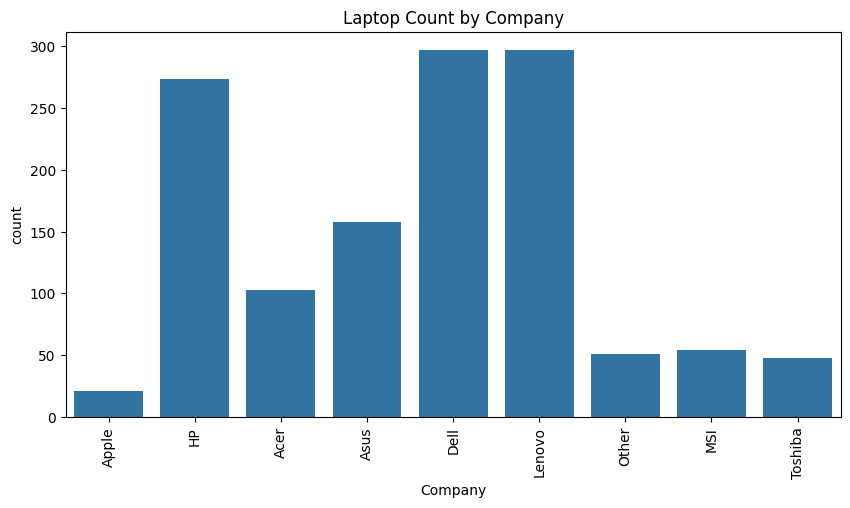

In [11]:

import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
sns.countplot(x="Company", data=data)
plt.xticks(rotation=90)
plt.title("Laptop Count by Company")
plt.show()

In [12]:
# Simplify Operating System
def set_os(inpt):
    if inpt in ['Windows 10','Windows 7','Windows 10 S']:
        return 'Windows'
    elif inpt in ['macOS','Mac OS X']:
        return 'Mac'
    elif inpt == 'Linux':
        return 'Linux'
    else:
        return 'Other'
data['OpSys'] = data['OpSys'].apply(set_os)

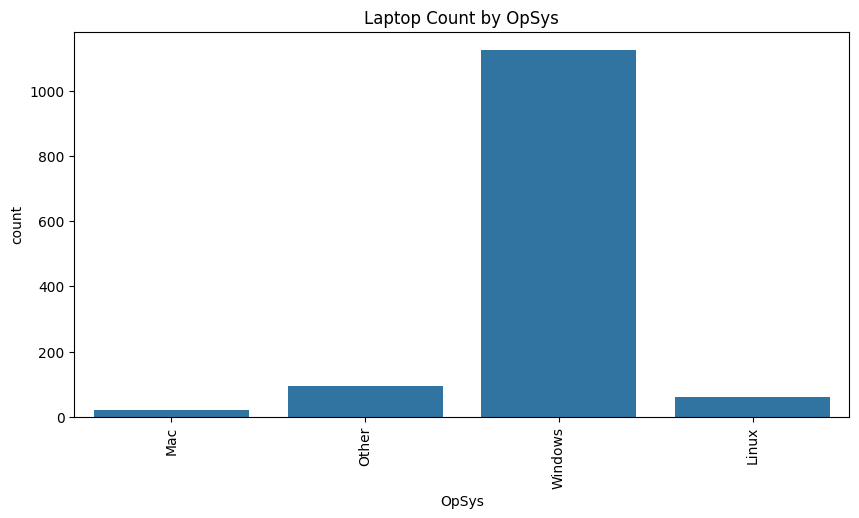

In [13]:
# Visualization
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
sns.countplot(x="OpSys", data=data)
plt.xticks(rotation=90)
plt.title("Laptop Count by OpSys")
plt.show()

# member 03

In [14]:
data['Touchscreen'] = data['ScreenResolution'].apply(lambda x:1 if 'Touchscreen' in x else 0)
data['Ips'] = data['ScreenResolution'].apply(lambda x:1 if 'IPS' in x else 0)

In [15]:
data.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros,Touchscreen,Ips
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,Mac,1.37,1339.69,0,1
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,Mac,1.34,898.94,0,0
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,Other,1.86,575.00,0,0
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,Mac,1.83,2537.45,0,1
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,Mac,1.37,1803.60,0,1


In [16]:
# CPU processing
data['cpu_name'] = data['Cpu'].apply(lambda x:" ".join(x.split()[0:3]))
def set_processor(name):
    if name in ['Intel Core i7','Intel Core i5','Intel Core i3']:
        return name
    elif name.split()[0] == 'AMD':
        return 'AMD'
    else:
        return 'Other'
data['cpu_name'] = data['cpu_name'].apply(set_processor)

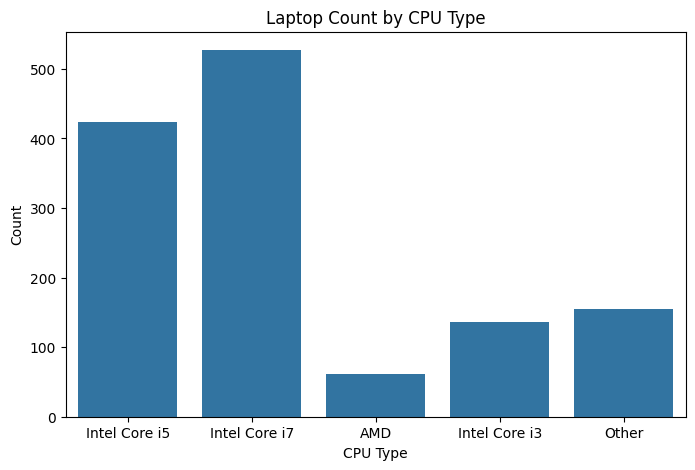

In [17]:
plt.figure(figsize=(8,5))
sns.countplot(x="cpu_name", data=data)
plt.title("Laptop Count by CPU Type")
plt.xlabel("CPU Type")
plt.ylabel("Count")
plt.show()

In [18]:
# GPU processing
data['gpu_name'] = data['Gpu'].apply(lambda x:" ".join(x.split()[0:1]))
data = data[data['gpu_name'] != 'ARM']  # remove ARM rows

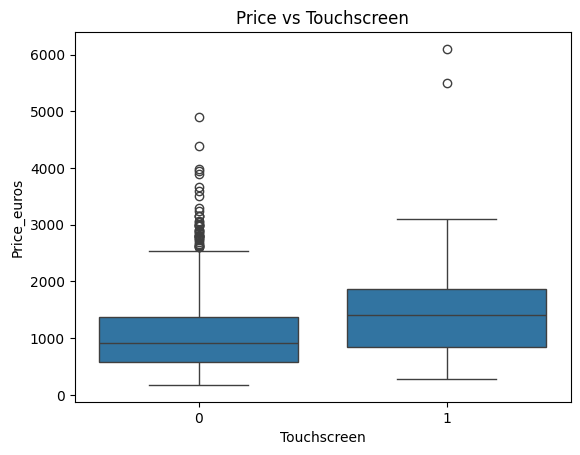

In [19]:
sns.boxplot(x="Touchscreen", y="Price_euros", data=data)
plt.title("Price vs Touchscreen")
plt.show()
# Boxplot shows touchscreen laptops are generally more expensive.
# This proves the importance of the new feature.

# member 04

In [20]:
import matplotlib.pyplot as plt

# Function to remove outliers using IQR
def remove_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[col] >= lower) & (df[col] <= upper)]

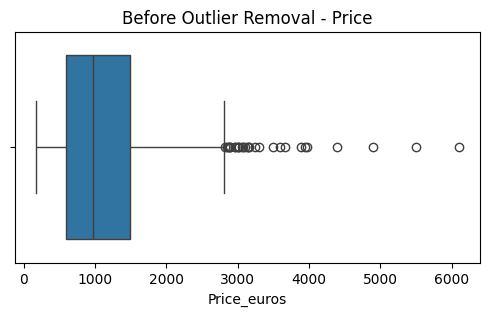

In [21]:
# Before Removal
plt.figure(figsize=(6,3))
sns.boxplot(x=data["Price_euros"])
plt.title("Before Outlier Removal - Price")
plt.show()

In [22]:
# Outlier Removal
cleaned_data = remove_outliers(data, "Price_euros")

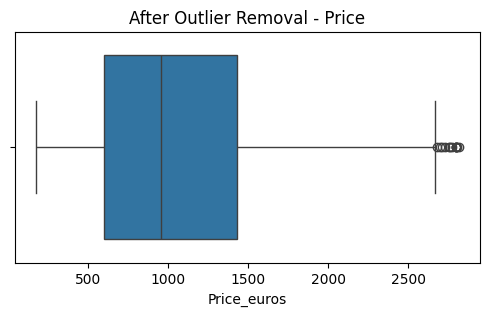

Before: 1302 After: 1273


In [23]:


# After Removal
plt.figure(figsize=(6,3))
sns.boxplot(x=cleaned_data["Price_euros"])
plt.title("After Outlier Removal - Price")
plt.show()

print("Before:", len(data), "After:", len(cleaned_data))

# member 05

In [24]:
data.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros,Touchscreen,Ips,cpu_name,gpu_name
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,Mac,1.37,1339.69,0,1,Intel Core i5,Intel
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,Mac,1.34,898.94,0,0,Intel Core i5,Intel
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,Other,1.86,575.00,0,0,Intel Core i5,Intel
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,Mac,1.83,2537.45,0,1,Intel Core i7,AMD
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,Mac,1.37,1803.60,0,1,Intel Core i5,Intel


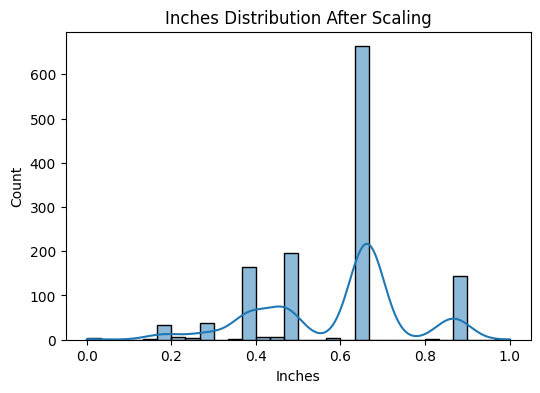

In [25]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
numeric_cols = cleaned_data.select_dtypes(include=["int64", "float64"]).columns
numeric_cols = numeric_cols.drop("Price_euros")  # exclude target
numeric_cols = numeric_cols.drop("laptop_ID")

cleaned_data.loc[:, numeric_cols] = scaler.fit_transform(cleaned_data[numeric_cols])


plt.figure(figsize=(6,4))
sns.histplot(cleaned_data["Inches"], bins=30, kde=True)
plt.title("Inches Distribution After Scaling")
plt.show()


# member 06

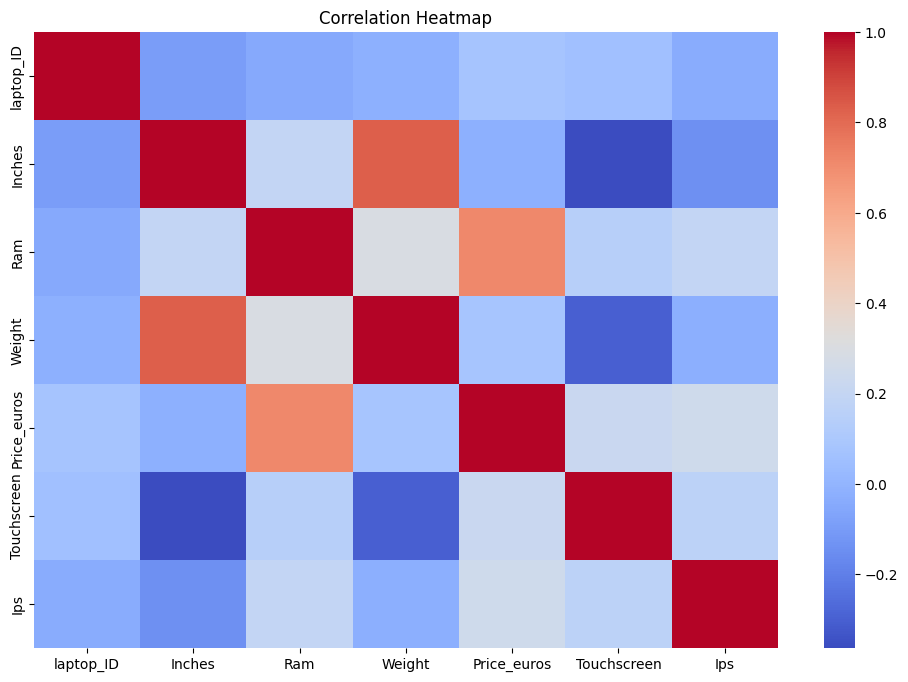

Explained Variance Ratio: [9.99866705e-01 1.28514471e-04 2.76983455e-06 1.29271633e-06
 6.65970567e-07 5.15082679e-08]


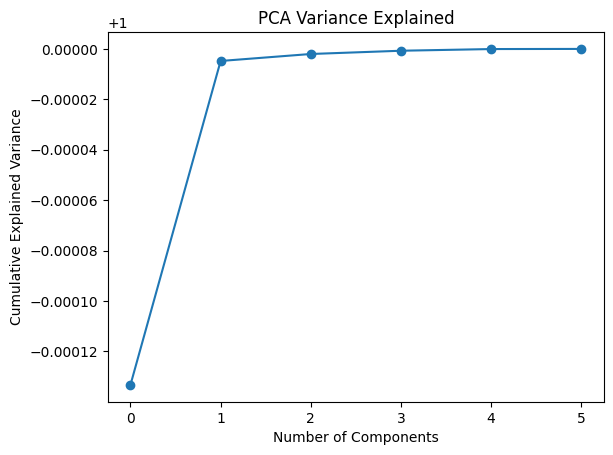

In [26]:
from sklearn.decomposition import PCA
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Drop non-numeric columns for correlation and PCA
cleaned_data_numeric = cleaned_data.select_dtypes(include=np.number)

# Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(cleaned_data_numeric.corr(), cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap")
plt.show()

# PCA
X = cleaned_data_numeric.drop("Price_euros", axis=1)
y = cleaned_data_numeric["Price_euros"]

pca = PCA(n_components=6)
X_pca = pca.fit_transform(X)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)

# PCA Variance Plot
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker="o")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Variance Explained")
plt.show()

In [27]:
data.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros,Touchscreen,Ips,cpu_name,gpu_name
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,Mac,1.37,1339.69,0,1,Intel Core i5,Intel
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,Mac,1.34,898.94,0,0,Intel Core i5,Intel
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,Other,1.86,575.00,0,0,Intel Core i5,Intel
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,Mac,1.83,2537.45,0,1,Intel Core i7,AMD
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,Mac,1.37,1803.60,0,1,Intel Core i5,Intel


In [28]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1302 entries, 0 to 1302
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   laptop_ID         1302 non-null   int64  
 1   Company           1302 non-null   object 
 2   Product           1302 non-null   object 
 3   TypeName          1302 non-null   object 
 4   Inches            1302 non-null   float64
 5   ScreenResolution  1302 non-null   object 
 6   Cpu               1302 non-null   object 
 7   Ram               1302 non-null   int32  
 8   Memory            1302 non-null   object 
 9   Gpu               1302 non-null   object 
 10  OpSys             1302 non-null   object 
 11  Weight            1302 non-null   float32
 12  Price_euros       1302 non-null   float64
 13  Touchscreen       1302 non-null   int64  
 14  Ips               1302 non-null   int64  
 15  cpu_name          1302 non-null   object 
 16  gpu_name          1302 non-null   object 
dtype

#Feature Selection

Filter Method

In [29]:
# Correlation with target (Price)
corr = data.corr(numeric_only=True)["Price_euros"].sort_values(ascending=False)
print(corr)

Price_euros    1.000000
Ram            0.742905
Ips            0.253320
Weight         0.209867
Touchscreen    0.192917
laptop_ID      0.068632
Inches         0.067329
Name: Price_euros, dtype: float64


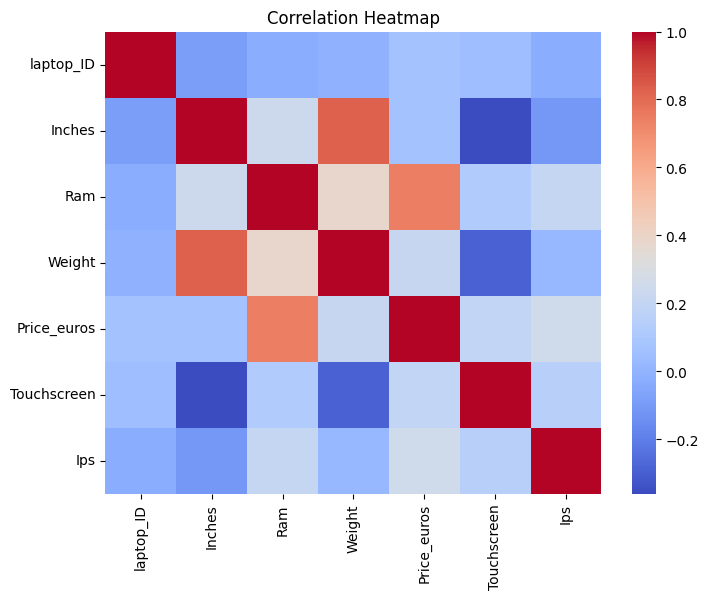

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(data.corr(numeric_only=True), annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

Embedded Method

In [31]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()
rf.fit(X, y)

importances = pd.Series(rf.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False)

# Show top features
print(top_features.head(10))

Ram            0.554521
Weight         0.209621
laptop_ID      0.164247
Inches         0.039940
Ips            0.017328
Touchscreen    0.014343
dtype: float64


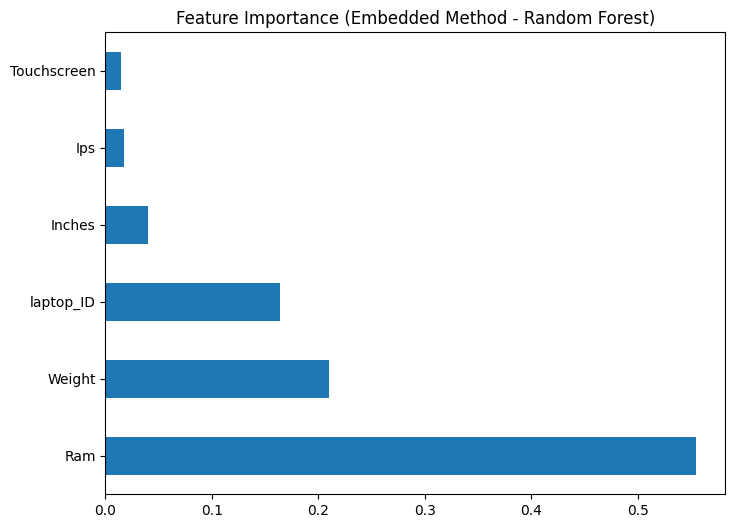

In [32]:
# Plot
top_features.head(10).plot(kind="barh", figsize=(8,6))
plt.title("Feature Importance (Embedded Method - Random Forest)")
plt.show()

#Drop column



In [33]:
final_data = cleaned_data.drop(columns=['Product','ScreenResolution','Cpu','Gpu','Memory'])


# One hot encoding

In [34]:
final_data = pd.get_dummies(final_data, dtype = int)


In [35]:
final_data.to_csv("preprocessed_laptopPrice.csv", index=False)

from google.colab import files
files.download("preprocessed_laptopPrice.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>